# Exploration de données — Sell4All

**Projet de sélection — Parcours Développement en Intelligence Artificielle (YouCode)**

**Auteur :** HAMID ASSOUAB
**Objectif :** Réaliser une première exploration des données clients de Sell4All (entreprise de vente de vêtements d'occasion en ligne) afin de préparer leur utilisation future dans un projet de recommandation par intelligence artificielle

Ce notebook contient, dans l'ordre :
1. Le chargement des données
2. Un premier aperçu (5 premières lignes)
3. Un résumé technique du jeu de données
4. Le calcul de statistiques descriptives (moyenne, médiane)
5. Une question bonus (médiane d'âge par pays)
6. Une visualisation des dépenses par pays
7. Le nettoyage des données (filtrage + suppression des doublons)
8. L'export du fichier CSV nettoyé


## 1. Import des bibliothèques

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## 2. Lecture du fichier CSV

In [4]:
df = pd.read_csv('dataset-sell4all.csv')
print("C'est bien")


C'est bien


## 3. Aperçu des 5 premières lignes

In [5]:
df.head()

,Name,Phone Number,Email,Address,Country,Postal code,Last date of connection,Last time of connection,Age,Gender,Customer spendings
0,Aaron Cote,966-7625,elit@hotmail.org,699-5837 Risus Street,Norway,4126,5-Apr-21,4:39,71,Man,356
1,Angelica Lawson,232-3051,diam.proin@google.org,481-8428 Magna. Street,Pakistan,518885,"oct. 10, 2021",0:36,37,Women,173
2,Louis Gilbert,1-997-733-0134,lorem.fringilla@hotmail.org,Ap #192-2082 Enim. Ave,Colombia,575444,2-Jul-22,3:37,24,Women,105
3,Basia Finley,1-987-322-7148,tristique.aliquet@icloud.co,608-2732 Nec Rd.,South Africa,5973-5765,19-Feb-22,2:34,37,Women,28
4,Rhona Sears,387-7682,iaculis.odio.nam@protonmail.org,8763 In Rd.,France,37476,31-Mar-22,6:28,42,Women,13


## 4. Résumé technique du jeu de données

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Name                     505 non-null    str  
 1   Phone Number             505 non-null    str  
 2   Email                    505 non-null    str  
 3   Address                  505 non-null    str  
 4   Country                  505 non-null    str  
 5   Postal code              505 non-null    str  
 6   Last date of connection  505 non-null    str  
 7   Last time of connection  505 non-null    str  
 8   Age                      505 non-null    int64
 9   Gender                   505 non-null    str  
 10  Customer spendings       505 non-null    int64
dtypes: int64(2), str(9)
memory usage: 43.5 KB


### 4. Explication du résumé technique du jeu de données

* **Combien y a-t-il d’entrées dans l’ensemble de données ?**
un total de 505 entrées (lignes), indexées de manière continue de 0 à 504 
* **Qu’est-ce que « non nul » ?**
 affichent toutes un total de 505 valeurs non nulles (non-null count). Cela confirme l'absence complète de valeurs manquantes ($NaN$) . Cela montre qu'une valeur non nulle est une cellule renseignée (qui n'est pas vide)
* **Quels types de données sont présents dans l’ensemble de données ? Quels sont ces types de données ?**
les types textuels (str) pour les variables qualitatives (nom, email, pays, etc.) et les types numériques entiers (int64) pour l'âge et les dépenses

## 5. Moyenne et médiane des colonnes « Age » et « Customer spendings »

In [8]:
age_mean = df['Age'].mean()
age_median = df['Age'].median()
spendings_mean = df['Customer spendings'].mean()
spendings_median = df['Customer spendings'].median()

print(f"Age moyen        : {age_mean:.2f} ans")
print(f"Age médian       : {age_median:.2f} ans")
print(f"Dépenses moyennes : {spendings_mean:.2f} €")
print(f"Dépenses médianes : {spendings_median:.2f} €")


Age moyen        : 46.08 ans
Age médian       : 46.00 ans
Dépenses moyennes : 311.17 €
Dépenses médianes : 307.00 €


## 6. Question bonus — Médiane d'âge par pays

In [9]:
median_age_by_country = df.groupby('Country')['Age'].median().sort_values(ascending=False)
median_age_by_country


Country
Turkey                60.0
France                56.5
Spain                 54.5
Norway                54.0
Germany               53.0
Philippines           51.0
Brazil                49.5
South Korea           49.5
Poland                49.5
Ireland               49.0
United States         48.5
United Kingdom        48.5
Netherlands           48.0
Vietnam               48.0
Costa Rica            48.0
Russian Federation    48.0
Mexico                47.0
Ukraine               46.0
Canada                46.0
Chile                 46.0
India                 45.5
Australia             44.0
Pakistan              44.0
South Africa          43.0
Austria               43.0
Singapore             41.5
Indonesia             41.5
Italy                 41.0
Sweden                40.0
Belgium               39.0
New Zealand           38.0
Peru                  38.0
Nigeria               37.0
China                 35.0
Colombia              29.0
Name: Age, dtype: float64

## 7. Visualisation — Dépenses des clients par pays

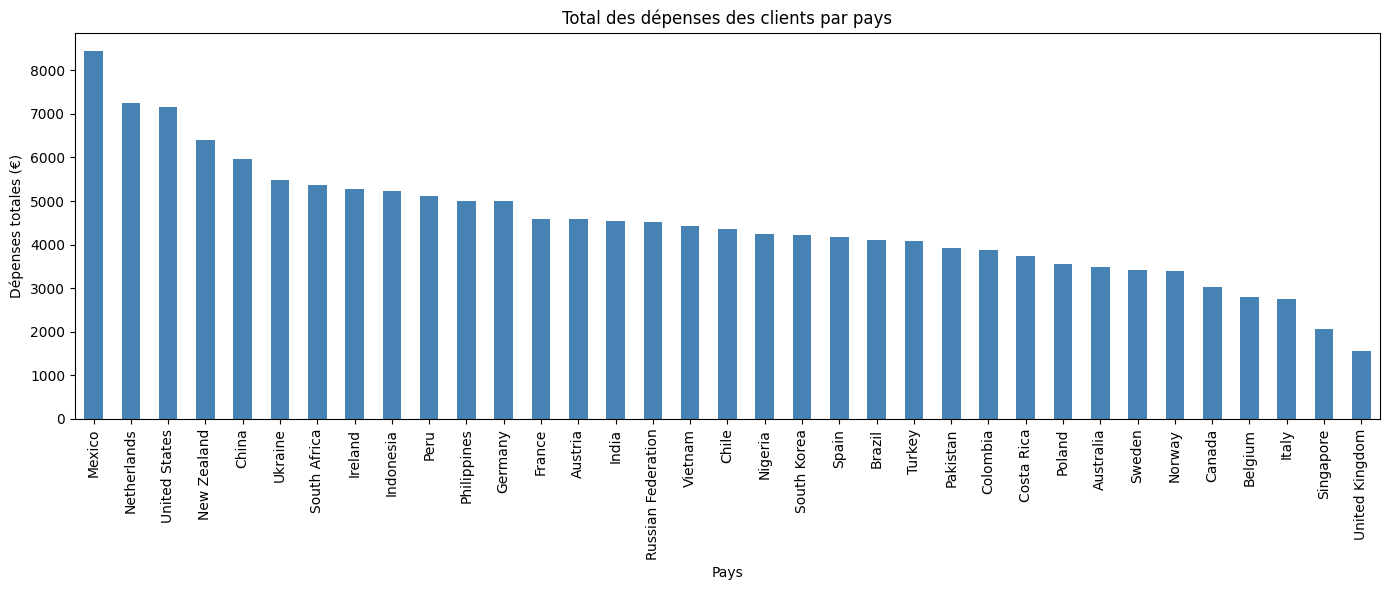

In [17]:
spendings_by_country = df.groupby('Country')['Customer spendings'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
spendings_by_country.plot(kind='bar', color='steelblue')
plt.title("Total des dépenses des clients par pays")
plt.xlabel("Pays")
plt.ylabel("Dépenses totales (€)")
plt.tight_layout()
plt.show()


## 8. Nettoyage des données

Deux opérations de nettoyage sont demandées :
1. Supprimer les lignes des utilisateurs ayant dépensé **moins de 10 €** sur le site
2. Supprimer les **doublons** (lignes strictement identiques apparaissant plusieurs fois)


In [ ]:
print("Nombre de lignes avant nettoyage :", len(df))

#supprime les lignes moins de 10€ de dépenses
df_clean = df[df['Customer spendings'] >= 10].copy()
print("Nombre de lignes après suppression des dépenses < 10€ :", len(df_clean))

#supprime les doublons
nb_doublons = df_clean.duplicated().sum()
print("Nombre de doublons trouvé :", nb_doublons)
df_clean = df_clean.drop_duplicates()
print("Nombre de lignes après suppression des doublons :", len(df_clean))


Nombre de lignes avant nettoyage : 505
Nombre de lignes après suppression des dépenses < 10€ : 502
Nombre de doublons détectés : 5
Nombre de lignes après suppression des doublons : 497


## 9. Export du fichier CSV nettoyé

`Country`, `Age`, `Gender`, `Customer spendings`.


In [ ]:
df_export = df_clean[['Country', 'Age', 'Gender', 'Customer spendings']]
df_export.to_csv('dataset-sell4all-clean.csv', index=False)
print("Fichier 'dataset-sell4all-clean.csv' généré avec succès")


Fichier 'dataset-sell4all-clean.csv' généré avec succès.


,Country,Age,Gender,Customer spendings
0,Norway,71,Man,356
1,Pakistan,37,Women,173
2,Colombia,24,Women,105
3,South Africa,37,Women,28
4,France,42,Women,13


## 10. Conclusion

Ces données sont maintenant plus fiables et pourront servir de base à l'entraînement d'un futur modèle de recommandation de produits